# 🌍 Climate Change Capstone — Data Investigation Blueprint

**ALL DATA CAPSONE INFORMATIONS ARE AT THE BOTTOM!!!**

Your Team's Roadmap Through the Full Data Science Lifecycle

Your dataset: Our World in Data — CO2 & Greenhouse Gas Emissions
Size: 50,411 rows × 79 columns — one row = one place, one year (1750s–present)

This document is your team's map for all five weeks. It won't hand you the answers — it hands you the questions. At the end of every week, come back to this page, answer the prompts as a team, and check off the deliverable. Everything you write here feeds directly into your STEAM Fair exhibit.

🗺️ Dataset Field Guide (Read This First)

You have 79 columns, but most of them are the same handful of ideas measured four different ways:

# 🗺️ Dataset Field Guide (Read This First)

This dataset contains **79 columns**, but most of them represent the same core concepts measured in different ways. Understanding these categories first will make the dataset much easier to work with.

| Category | Example Columns | What It's Really Asking |
|----------|-----------------|-------------------------|
| **Identity** | `country`, `year`, `iso_code` | Where and when is this observation? |
| **Context** | `population`, `gdp` | How large is this country in terms of people and economy? |
| **Total Emissions** | `co2`, `total_ghg`, `methane`, `nitrous_oxide` | How much pollution is produced in total? |
| **Per-Person Emissions** | `co2_per_capita` | How much pollution does the average resident contribute? This can produce rankings very different from total emissions. |
| **Change Over Time** | `co2_growth_abs`, `co2_growth_prct` | Are emissions increasing or decreasing, and by how much? |
| **Source Breakdown** | `cement_co2`, `coal_co2`, `oil_co2`, `gas_co2`, `flaring_co2` | Which sectors or fuel sources generate the emissions? |
| **World Share** | `share_global_co2` | What percentage of the world's emissions comes from this country? |
| **Trade** | `trade_co2` | How much CO₂ is effectively imported or exported through international trade? |
| **Temperature Impact** | `temperature_change_from_co2`, `temperature_change_from_ghg` | How much has this country's emissions contributed to global warming (°C)? |

---

## ⚠️ Important Things to Know Before Analyzing

### 1. Not Every Row Represents a Country

Some rows correspond to **aggregated regions or groups** rather than individual countries. Examples include:

- World
- Asia
- Europe
- High-income countries
- Low-income countries

These aggregate rows often have a **missing (`NaN`) `iso_code`**.

If you do not filter them out, you may accidentally compare a single country (such as France) with an entire continent (such as Asia), leading to misleading results.

---

### 2. Missing Data Is Not Random

Missing values carry important information.

Older years (especially **1750–1900**) and many **small or lower-income countries** have substantially more missing data than larger, wealthier countries with modern reporting systems.

This means missingness reflects historical reporting practices—not just incomplete data.

When performing analyses, always consider:

- the time period,
- the country's reporting history,
- and whether missing values could bias your conclusions.

In many cases, the pattern of missing data is itself part of the story.

In [ ]:
# importing necessary libraries
import pandas as pd

# fetching the url where the dataset is located
# Pre-cleaned version on Kaggle (requires Kaggle API key)
# OR use this CDC direct CSV — age-adjusted prevalence, no login:
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

# loading the dataset
df = pd.read_csv(url)

# printing the rows and columns of the dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# displaying 5 random values
df.sample(5)

df.shape

Shape: 50411 rows × 79 columns


(50411, 79)

# # Week 1 Student To-Do List: Empathize Phase — Climate Change Team

**Domain:** Climate Change  
**Dataset:** Our World in Data (OWID) CO₂ & Greenhouse Gas Emissions *(50,411 rows × 79 columns)*

---

# Essential Question

### **"What is this data hiding, and who is missing from it?"**

---

# Monday — Meet Your Dataset

### ✅ 1. Open your dataset in Google Colab

Load the dataset and display the first few rows.

**Function Hint**

```python
df.head(10)
```

**Ask yourself**

- Each row represents one country (or region) in one year.
- Do you notice that some entries in the **country** column are not actually countries?
- Why might rows such as **World**, **Asia**, or **High-income countries** be included?

---

### ✅ 2. Check the size of your dataset

**Function Hint**

```python
df.shape
```

**Ask yourself**

- How many rows are in the dataset?
- How many columns describe each row?
- Why might a climate dataset need nearly 80 different variables?

---

### ✅ 3. Explore the column names

**Function Hint**

```python
df.columns
```

**Look for**

Circle or highlight any unfamiliar columns, especially ones such as:

- `temperature_change_from_...`
- `share_global_...`
- `co2_per_capita`
- `trade_co2`
- `total_ghg`

Write down questions your team has about these variables.

---

### ✅ 4. Learn what key variables mean

Use your instructor's **OWID Codebook** to find the definitions of:

- `co2`
- `total_ghg`
- `trade_co2`

Record each definition in your notebook.

---

### ✅ 5. Data Journal Reflection

**Prompt**

> What global challenge makes you want to explore climate data? Why does it matter?

---

# Tuesday — Get to Know the Numbers

### ✅ 1. Check the data types

**Function Hint**

```python
df.dtypes
```

**Ask yourself**

- Which columns contain text?
- Which columns contain whole numbers?
- Which columns contain decimal numbers?
- Why do CO₂ emissions need decimal values instead of whole numbers?

---

### ✅ 2. Explore descriptive statistics

**Function Hint**

```python
df[['co2', 'co2_per_capita', 'total_ghg']].describe()
```

**Look for**

- Mean
- Median
- Minimum
- Maximum
- Standard deviation

**Think about**

- Compare the mean and median of **co2**.
- If the mean is much larger than the median, what does that suggest about the distribution?

---

### ✅ 3. Count the number of rows for each country

**Function Hint**

```python
df['country'].value_counts()
```

**Ask yourself**

- Which countries have the most years of data?
- Which countries have only a few years?
- Why might some countries have much longer historical records than others?

---

### ✅ 4. Write two observations

Write:

- One numerical fact you discovered (include units, such as **million tonnes of CO₂**).
- One sentence explaining what that number tells you about a country or region.

---

### ✅ 5. Data Journal Reflection

**Prompt**

> How do you think this data was collected? Which countries or regions might have incomplete records?

---

# Wednesday — Find the Gaps (Colab Lab)

### ✅ 1. Check for missing values

**Function Hint**

```python
df.isnull().sum()
```

**Ask yourself**

- Which columns have the most missing values?
- Are some missing values expected?
- For example, should a row representing **Europe** or **World** have its own GDP or population?

---

### ✅ 2. Compare average CO₂ emissions by country

**Function Hint**

```python
df.groupby('country')['co2'].mean()
```

**Think about**

- Which countries have the highest average emissions?
- What factors might explain these differences?
  - Population
  - Industrial activity
  - Energy use
  - Number of years included

---

### ✅ 3. Create your first chart

**Function Hint**

```python
df['co2_per_capita'].hist()
```

**Look for**

- Is the distribution symmetric or skewed?
- Do most countries have relatively low emissions per person?
- Are there a few countries with extremely high values?

---

### ✅ 4. Write a Data Empathy Statement

Use this template:

> **Our dataset measures** carbon dioxide and greenhouse gas emissions across countries and regions over time, **collected from multiple international statistical and scientific sources and compiled by Our World in Data**. It helps us understand long-term emission trends, but it cannot explain the political, economic, or social reasons behind those changes, and some countries or years may have incomplete data.

---

### ✅ 5. Data Journal Reflection

**Prompt**

> Who collected this data? Which places or time periods might be missing or less reliable?

---

# Thursday — Check Your Understanding

Complete the following:

- ✅ Take the Descriptive Statistics Quiz
- ✅ Submit your Exploratory Data Analysis (EDA) notebook to GitHub
- ✅ Make sure every chart includes:
  - A clear title
  - Labeled axes
  - One sentence explaining the main finding
- ✅ Participate in the Evidence & Action discussion
- ✅ Complete the Descriptive Statistics problem set
- ✅ Finish your Week 1 Data Journal reflection

---

# End of Week 1 Checkpoint

By the end of this week, you should be able to explain:

- How many rows and columns are in your dataset.
- The time period covered by the data.
- The mean, median, and standard deviation of CO₂ emissions.
- One important thing this dataset cannot tell you.
- Why some rows in the **country** column are actually regions or income groups instead of individual countries.
- Why understanding what is **missing** from a dataset is just as important as understanding what is included.

In [ ]:
# ALL DATA ARE AT THE BOTTOM!!!

print("ALL DATA ARE AT THE BOTTOM!!!")
print("ALL DATA ARE AT THE BOTTOM!!!")
print("ALL DATA ARE AT THE BOTTOM!!!")
print("ALL DATA ARE AT THE BOTTOM!!!")
print("ALL DATA ARE AT THE BOTTOM!!!")
print("ALL DATA ARE AT THE BOTTOM!!!")

ALL DATA ARE AT THE BOTTOM!!!
ALL DATA ARE AT THE BOTTOM!!!
ALL DATA ARE AT THE BOTTOM!!!
ALL DATA ARE AT THE BOTTOM!!!
ALL DATA ARE AT THE BOTTOM!!!
ALL DATA ARE AT THE BOTTOM!!!


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

# Week 2 Student To-Do List: Define Phase — Climate Change Team

**Domain:** Climate Change  
**Dataset:** Our World in Data (OWID) CO₂ & Greenhouse Gas Emissions

---

# Essential Question

### **"Is this chart telling the truth—and did I clean the data honestly?"**

---

# Monday — Fix the Foundation

### ✅ 1. Find the rows that are not individual countries

**Function Hint**

```python
df[df['iso_code'].isnull()]['country'].unique()
```

**Ask yourself**

- Which entries are regions or groups instead of countries?
- Examples include:
  - World
  - Asia
  - Africa
  - High-income countries
- Why might these rows be included in the dataset?

---

### ✅ 2. Decide whether to keep or remove aggregate rows

**Function Hint**

```python
df_countries = df[df['iso_code'].notnull()]
```

**Think critically**

- Should your analysis include regions like **World** and **Asia**, or only individual countries?
- How might including aggregate rows affect averages, charts, or conclusions?
- Record your team's decision and explain why.

---

### ✅ 3. Check for missing values in important columns

**Function Hint**

```python
df_countries[['co2', 'population', 'gdp']].isnull().sum()
```

**Ask yourself**

- Which columns contain the most missing values?
- Are older years missing more information than recent years?
- Is the missing data random, or does it follow a pattern?

---

### ✅ 4. Check for duplicate rows

**Function Hint**

```python
df_countries.duplicated().sum()
```

**Think about**

- Are there any duplicate country-year records?
- If duplicates exist, investigate them before continuing.

---

### ✅ 5. Look for unusual values (outliers)

**Function Hint**

```python
df_countries['co2_growth_prct'].describe()
```

**Ask yourself**

- Are there extremely large increases or decreases?
- Could these values represent real events rather than data errors?
- Should every outlier be removed?

---

### ✅ 6. Write a Data Cleaning Plan

Create a table like this:

| Issue Found | Decision | Why? |
|-------------|----------|------|
| Aggregate rows (World, Asia, etc.) | Remove | Compare only individual countries |
| Missing GDP values | Keep missing values | Older years often lack reliable GDP data |
| Duplicate rows | Remove if found | Prevent counting the same record twice |
| Extreme CO₂ growth values | Keep and investigate | May represent real historical events |

---

### ✅ 7. Data Journal Reflection

**Prompt**

> What data did your team remove or keep today? Who might be systematically missing from your cleaned dataset?

---

# Tuesday — Choose the Right Chart, Tell the Truth

### ✅ 1. Warm-Up: Spot the Misleading Chart

Examine 2–3 published climate charts provided by your instructor.

For each chart, discuss:

- What is the chart trying to convince the reader?
- What does the underlying data actually show?
- Could the design of the chart be misleading?

---

### ✅ 2. Compare total CO₂ emissions across countries

**Function Hint**

```python
sns.barplot(
    data=df_countries,
    x='country',
    y='co2'
)
```

**Look for**

- Which countries have the highest emissions?
- Does your title communicate a finding instead of simply describing the chart?

Example:

> **China and the United States produce much higher total CO₂ emissions than most other countries.**

---

### ✅ 3. Explore CO₂ emissions per person

**Function Hint**

```python
sns.histplot(df_countries['co2_per_capita'])
```

**Ask yourself**

- Where do most countries fall?
- Is the distribution skewed?
- What do a few very high values tell us?

---

### ✅ 4. Examine global CO₂ emissions over time

**Function Hint**

```python
sns.lineplot(
    data=df[df['country'] == 'World'],
    x='year',
    y='co2'
)
```

**Think about**

- Does the graph begin at zero?
- How can changing the axis make trends appear larger or smaller?

---

### ✅ 5. Compare GDP and CO₂ emissions

**Function Hint**

```python
sns.scatterplot(
    data=df_countries,
    x='gdp',
    y='co2',
    hue='continent'
)
```

**Look for**

- Do wealthier countries generally produce more emissions?
- Which countries do not follow the overall pattern?

---

### ✅ Every chart must include

- A finding-based title
- Clearly labeled axes
- Units (when appropriate)
- Two sentences explaining what the chart shows

---

### ✅ Data Journal Reflection

**Prompt**

> Which chart could become misleading if you changed the axes or selected only part of the data?

---

# Wednesday — Clean, Visualize, and Define

## Step 1 — Audit the Data

Run:

```python
df.info()
```

```python
df.describe()
```

```python
df.isnull().sum()
```

Write a short **Data Audit Report** describing every quality issue you found.

---

## Step 2 — Clean the Data

Apply your documented cleaning pipeline.

Example:

```python
df_countries = df[df['iso_code'].notnull()]
```

Verify your work:

```python
assert df_countries['iso_code'].isnull().sum() == 0
```

Explain each cleaning decision in a Markdown cell.

---

## Step 3 — Create Visualizations

Create:

- Histogram
- Bar chart
- Line chart
- Scatter plot

Each chart must include:

- Finding-based title
- Labeled axes
- Units
- Two-sentence interpretation

### ⭐ Challenge

Create one chart that challenges a common assumption.

Example:

> Does the country with the largest population also have the highest CO₂ emissions per person?

---

## Step 4 — Write a Data Brief

Write **about 150 words** explaining your three most important findings in language that a city council member could understand.

---

## Step 5 — Write a Data Problem Statement

Use this template:

> **Our investigation asks:** *(Write a clear, answerable question.)*
>
> We are using the **Our World in Data CO₂ and Greenhouse Gas Emissions dataset**, which contains one row for each country (or region) in each year.
>
> Our main variable is **__________________**, measured in **__________________**.
>
> This investigation matters because understanding this pattern can help governments and communities make better decisions about climate change.
>
> We will consider a finding meaningful if **__________________**.

Submit your Problem Statement for instructor feedback.

---

# Thursday — Check Your Understanding

Complete the following:

- ✅ Take the Data Visualization Quiz
- ✅ Submit your Data Cleaning & Visualization notebook to GitHub
- ✅ Participate in the Evidence & Action discussion
- ✅ Complete the Visualization Analysis Assignment
- ✅ Meet with your instructor for your Capstone check-in

---

# End of Week 2 Checkpoint

By the end of this week, you should be able to explain:

- Why your team kept or removed the **World**, continent, or income-group rows.
- How those rows could affect averages and charts.
- One chart you created, its finding-based title, and the units on both axes.
- One example of how a climate chart could mislead readers through axis choices or time ranges.
- Your team's one-sentence Data Problem Statement written in clear, everyday language.

# **DATA SCIENCE DATA ANALYSIS WITH COMPUTERS AND DATA**

# **DATA CLEANING 1**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)


# 1. Filter out regional/aggregate ISO codes (OWID_*) to keep only actual countries
df_countries = df[df['iso_code'].notnull() & ~df['iso_code'].str.startswith('OWID').fillna(False)].copy()

# 2. Select columns of interest to make the dataframe lightweight and easy to work with
cols_to_keep = ['country', 'iso_code', 'year', 'co2', 'co2_per_capita', 'gdp', 'population', 'cement_co2']

df_clean = df_countries[cols_to_keep].dropna(subset=['co2'])

# 3. Filter for modern data (e.g., from 1850 onwards)
df_clean = df_clean[df_clean['year'] >= 1850]

print("Data Cleaning Complete!")
print(df_clean.head(1000000))

Data Cleaning Complete!
           country iso_code  year     co2  co2_per_capita           gdp  \
199    Afghanistan      AFG  1949   0.015           0.002           NaN   
200    Afghanistan      AFG  1950   0.084           0.011  9.421400e+09   
201    Afghanistan      AFG  1951   0.092           0.012  9.692280e+09   
202    Afghanistan      AFG  1952   0.092           0.011  1.001732e+10   
203    Afghanistan      AFG  1953   0.106           0.013  1.063052e+10   
...            ...      ...   ...     ...             ...           ...   
50406     Zimbabwe      ZWE  2020   8.491           0.547  2.317871e+10   
50407     Zimbabwe      ZWE  2021  10.223           0.647  2.514009e+10   
50408     Zimbabwe      ZWE  2022  12.232           0.761  2.590159e+10   
50409     Zimbabwe      ZWE  2023  13.443           0.823           NaN   
50410     Zimbabwe      ZWE  2024  13.701           0.824           NaN   

       population  cement_co2  
199     7356890.0       0.000  
200     777

/tmp/ipykernel_1661/4054626724.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_countries = df[df['iso_code'].notnull() & ~df['iso_code'].str.startswith('OWID').fillna(False)].copy()


# **CHARTS**




Correlation Matrix for Selected Variables:
                              co2   gdp  population  cement_co2  coal_co2  \
co2                          1.00  0.92        0.63        0.77      0.92   
gdp                          0.92  1.00        0.61        0.70      0.80   
population                   0.63  0.61        1.00        0.66      0.70   
cement_co2                   0.77  0.70        0.66        1.00      0.91   
coal_co2                     0.92  0.80        0.70        0.91      1.00   
oil_co2                      0.87  0.85        0.41        0.41      0.63   
gas_co2                      0.75  0.76        0.26        0.26      0.46   
temperature_change_from_co2  0.86  0.85        0.44        0.40      0.65   
total_ghg                    0.96  0.88        0.70        0.71      0.89   
year                         0.10  0.19        0.08        0.11      0.04   

                             oil_co2  gas_co2  temperature_change_from_co2  \
co2                            

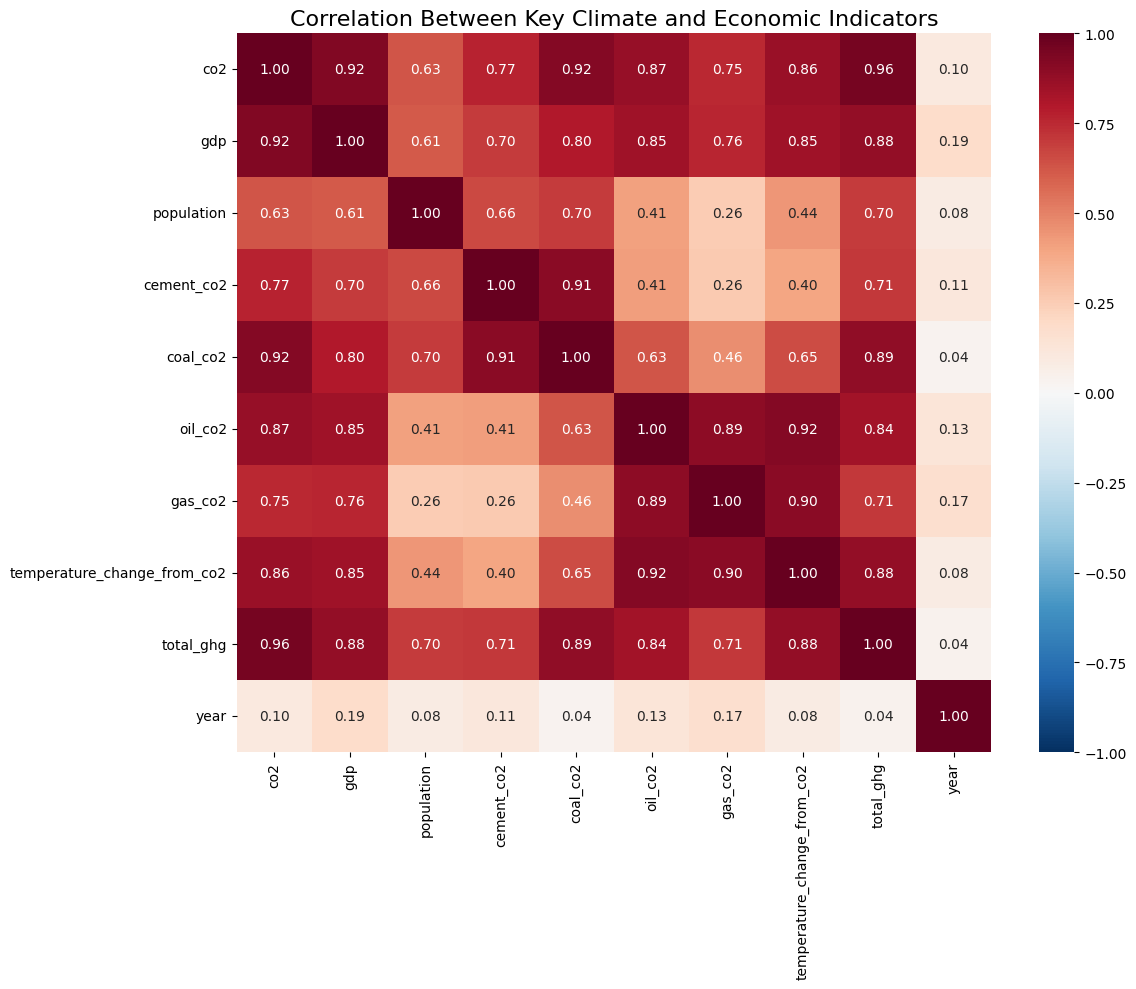

Interesting... everything has a correlation?


In [ ]:
# Select a subset of relevant numeric columns for a more readable correlation matrix
selected_columns = [
    'co2', 'gdp', 'population', 'cement_co2', 'coal_co2', 'oil_co2', 'gas_co2',
    'temperature_change_from_co2', 'total_ghg', 'year'
]

# Filter the original DataFrame to include only these selected columns and drop rows with any NaNs for accurate correlation
# Use df_countries for actual country data, not global aggregates
df_filtered_for_corr = df_countries[selected_columns].dropna()

# Calculate the correlation matrix for the selected columns
correlation_matrix_filtered = df_filtered_for_corr.corr()
print("Correlation Matrix for Selected Variables:")
print(correlation_matrix_filtered.round(2))

# Heatmap — colorblind-accessible colormap, with increased figure size and font size for readability
plt.figure(figsize=(12, 10)) # Increased figure size
sns.heatmap(correlation_matrix_filtered, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt=".2f", annot_kws={"size": 10}) # Added fmt and annot_kws

# Finding-based title
plt.title("Correlation Between Key Climate and Economic Indicators", fontsize=16)
plt.tight_layout()
plt.show()


print("Interesting... everything has a correlation?")

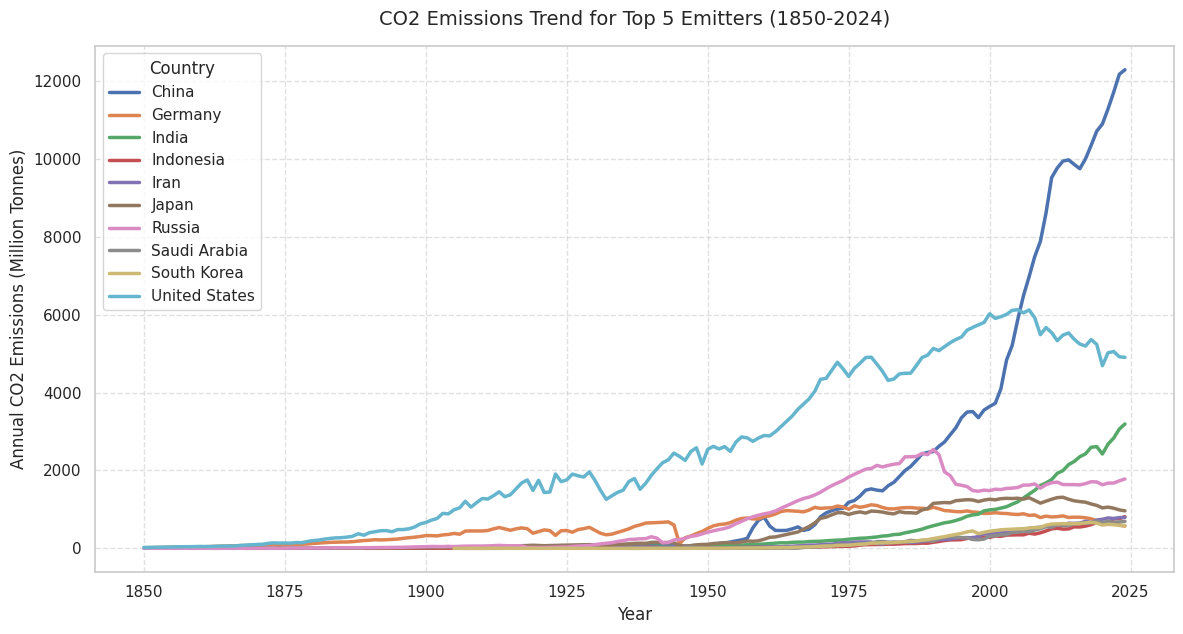

This is a line plot. It shows how much Co2 Emissions a countries does over time


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

latest_year = df_clean['year'].max()


top_emitters = df_clean[df_clean['year'] == latest_year].nlargest(10, 'co2')



# Get the list of the top 5 country names from the analysis step
top_country_names = top_emitters['country'].tolist()



# Filter our main cleaned dataframe for only these 5 countries
df_plot = df_clean[df_clean['country'].isin(top_country_names)]

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6.5))
sns.lineplot(data=df_plot, x='year', y='co2', hue='country', linewidth=2.5)

# Formatting
plt.title(f'CO2 Emissions Trend for Top 5 Emitters (1850-{latest_year})', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Annual CO2 Emissions (Million Tonnes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country', frameon=True)

# Adjust layout and display
plt.tight_layout()
plt.show()

print("This is a line plot. It shows how much Co2 Emissions a countries does over time")

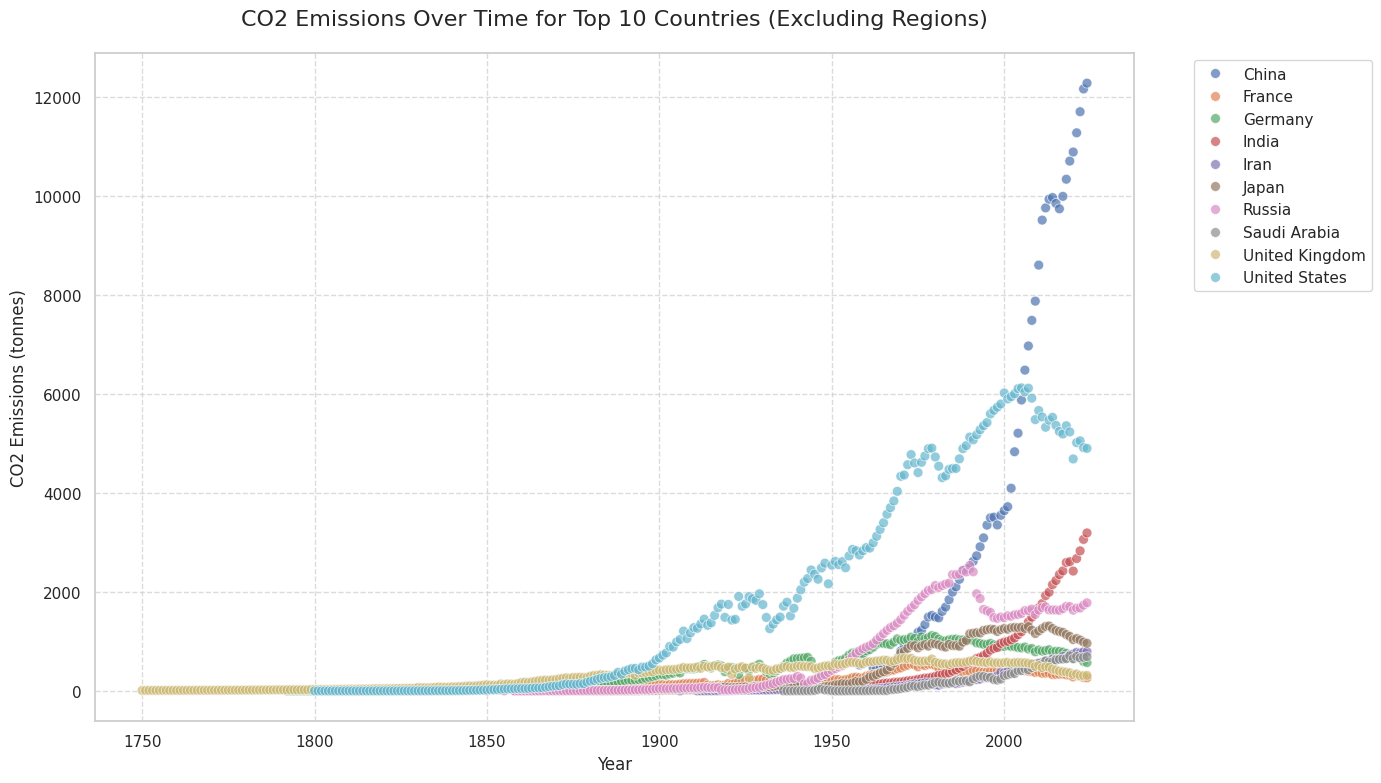

This is a dot plot. It shows how much Co2 Emissions a countries does over time


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)


# Exclude aggregate regions based on iso_code (as performed in a previous step)
df_countries = df[df['iso_code'].notnull()].copy()


# Additionally, explicitly exclude known aggregate regions that might have iso_codes or weren't caught
regions_to_exclude = [
   'World', 'European Union (27)', 'European Union (28)',
   'High-income countries', 'Low-income countries',
   'Lower-middle-income countries', 'Upper-middle-income countries',
   'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania',
   'International aviation', 'International shipping',
   'OECD (GCP)', 'Non-OECD (GCP)', 'Africa (GCP)', 'Asia (GCP)',
   'Europe (GCP)', 'North America (GCP)', 'South America (GCP)',
   'Oceania (GCP)', 'Least developed countries (Jones et al.)', 'Kosovo', 'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)'
]


df_countries = df_countries[~df_countries['country'].isin(regions_to_exclude)].copy()




# Calculate average CO2 emissions per country using df_countries
avg_co2_per_country = df_countries.groupby('country')['co2'].mean().sort_values(ascending=False)


# Select the top N countries for better visualization
n_countries = 10
top_n_countries_co2 = avg_co2_per_country.head(n_countries)

# Filter df_countries to only include the top N countries
df_top_countries = df_countries[df_countries['country'].isin(top_n_countries_co2.index)]

plt.figure(figsize=(14, 8))

# Scatter Plot: CO2 emissions over time for top N countries
sns.scatterplot(
    data=df_top_countries,
    x='year',
    y='co2',
    hue='country', # Differentiate countries by color
    s=50,          # Size of the points
    alpha=0.7      # Transparency of the points
)

plt.title(f'CO2 Emissions Over Time for Top {n_countries} Countries (Excluding Regions)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Emissions (tonnes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout()
plt.show()

# Bar Chart (often preferred for comparing values across categories)
# plt.figure(figsize=(12, 8))
# sns.barplot(
#    x=top_n_countries_co2.values,
#    y=top_n_countries_co2.index,
#    palette='viridis'
# )
# plt.xlabel('Average CO2 Emissions (tonnes)', fontsize=12)
# plt.ylabel('Country', fontsize=12)
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.title(f'Top {n_countries} Countries by Average CO2 Emissions (Excluding Regions)', fontsize=16, pad=20)
# plt.tight_layout()
# plt.show()

# Pie Chart (useful for showing parts of a whole, but less ideal for direct comparison of magnitudes)
# plt.figure(figsize=(12, 8))
# plt.pie(
#    x=top_n_countries_co2.values,
#    labels=top_n_countries_co2.index,
#    autopct='%1.1f%%', # Display percentages on wedges
#    startangle=90,    # Start the first slice at 90 degrees (top)
#    counterclock=False # Draw wedges counter-clockwise
# )
# plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
# plt.title(f'Top {n_countries} Countries by Average CO2 Emissions (Excluding Regions)', fontsize=16, pad=20)
# plt.tight_layout()
# plt.show()

print("This is a dot plot. It shows how much Co2 Emissions a countries does over time")

<Figure size 1400x800 with 0 Axes>

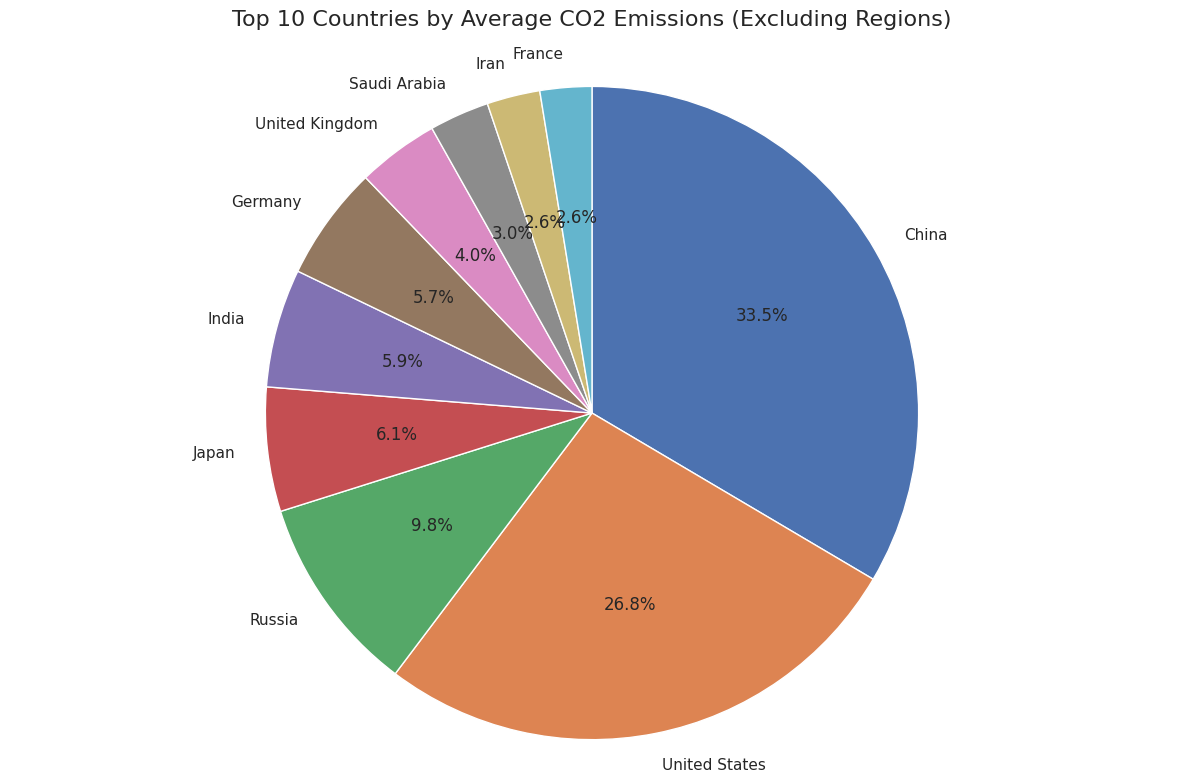

This is a Pie Circle Chart. It shows how much Co2 Emissions a countries does.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)


# Exclude aggregate regions based on iso_code (as performed in a previous step)
df_countries = df[df['iso_code'].notnull()].copy()


# Additionally, explicitly exclude known aggregate regions that might have iso_codes or weren't caught
regions_to_exclude = [
   'World', 'European Union (27)', 'European Union (28)',
   'High-income countries', 'Low-income countries',
   'Lower-middle-income countries', 'Upper-middle-income countries',
   'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania',
   'International aviation', 'International shipping',
   'OECD (GCP)', 'Non-OECD (GCP)', 'Africa (GCP)', 'Asia (GCP)',
   'Europe (GCP)', 'North America (GCP)', 'South America (GCP)',
   'Oceania (GCP)', 'Least developed countries (Jones et al.)', 'Kosovo', 'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)'
]


df_countries = df_countries[~df_countries['country'].isin(regions_to_exclude)].copy()




# Calculate average CO2 emissions per country using df_countries
avg_co2_per_country = df_countries.groupby('country')['co2'].mean().sort_values(ascending=False)


# Select the top N countries for better visualization
n_countries = 10
top_n_countries_co2 = avg_co2_per_country.head(n_countries)

# Filter df_countries to only include the top N countries
df_top_countries = df_countries[df_countries['country'].isin(top_n_countries_co2.index)]

plt.figure(figsize=(14, 8))

# Scatter Plot: CO2 emissions over time for top N countries
# sns.scatterplot(
    # data=df_top_countries,
    # x='year',
    # y='co2',
    # hue='country', # Differentiate countries by color
    # s=50,          # Size of the points
    # alpha=0.7      # Transparency of the points
# )

# plt.title(f'CO2 Emissions Over Time for Top {n_countries} Countries (Excluding Regions)', fontsize=16, pad=20)
# plt.xlabel('Year', fontsize=12)
# plt.ylabel('CO2 Emissions (tonnes)', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
# plt.tight_layout()
# plt.show()

# Bar Chart (often preferred for comparing values across categories)
# plt.figure(figsize=(12, 8))
# sns.barplot(
#     x=top_n_countries_co2.values,
#     y=top_n_countries_co2.index,
#     palette='viridis'
#  )
# plt.xlabel('Average CO2 Emissions (tonnes)', fontsize=12)
# plt.ylabel('Country', fontsize=12)
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.title(f'Top {n_countries} Countries by Average CO2 Emissions (Excluding Regions)', fontsize=16, pad=20)
# plt.tight_layout()
# plt.show()

# Pie Chart (useful for showing parts of a whole, but less ideal for direct comparison of magnitudes)
plt.figure(figsize=(12, 8))
plt.pie(
   x=top_n_countries_co2.values,
   labels=top_n_countries_co2.index,
   autopct='%1.1f%%', # Display percentages on wedges
   startangle=90,    # Start the first slice at 90 degrees (top)
   counterclock=False # Draw wedges counter-clockwise
)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title(f'Top {n_countries} Countries by Average CO2 Emissions (Excluding Regions)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("This is a Pie Circle Chart. It shows how much Co2 Emissions a countries does.")

/tmp/ipykernel_1661/2349767616.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Figure size 1400x800 with 0 Axes>

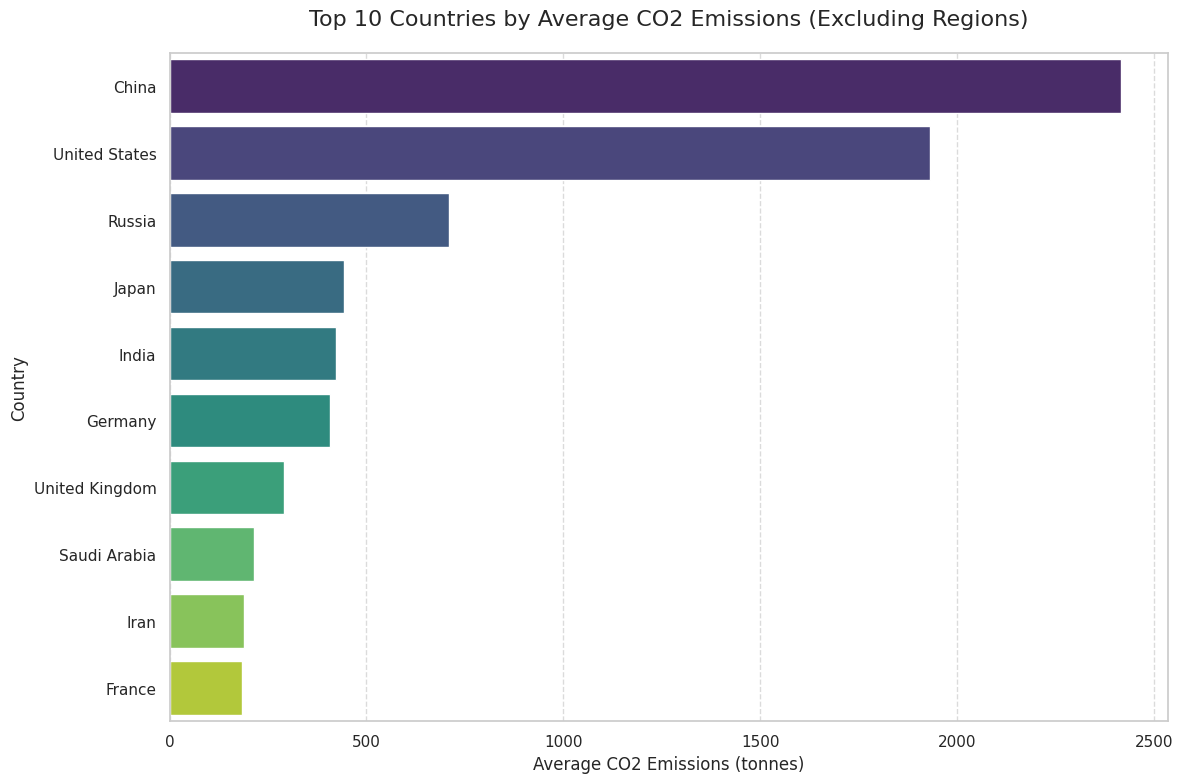

This is a Bar Chart. It shows how much Co2 Emissions a countries does.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)


# Exclude aggregate regions based on iso_code (as performed in a previous step)
df_countries = df[df['iso_code'].notnull()].copy()


# Additionally, explicitly exclude known aggregate regions that might have iso_codes or weren't caught
regions_to_exclude = [
   'World', 'European Union (27)', 'European Union (28)',
   'High-income countries', 'Low-income countries',
   'Lower-middle-income countries', 'Upper-middle-income countries',
   'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania',
   'International aviation', 'International shipping',
   'OECD (GCP)', 'Non-OECD (GCP)', 'Africa (GCP)', 'Asia (GCP)',
   'Europe (GCP)', 'North America (GCP)', 'South America (GCP)',
   'Oceania (GCP)', 'Least developed countries (Jones et al.)', 'Kosovo', 'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)'
]


df_countries = df_countries[~df_countries['country'].isin(regions_to_exclude)].copy()




# Calculate average CO2 emissions per country using df_countries
avg_co2_per_country = df_countries.groupby('country')['co2'].mean().sort_values(ascending=False)


# Select the top N countries for better visualization
n_countries = 10
top_n_countries_co2 = avg_co2_per_country.head(n_countries)

# Filter df_countries to only include the top N countries
df_top_countries = df_countries[df_countries['country'].isin(top_n_countries_co2.index)]

plt.figure(figsize=(14, 8))

# Scatter Plot: CO2 emissions over time for top N countries
# sns.scatterplot(
    # data=df_top_countries,
    # x='year',
    # y='co2',
    # hue='country', # Differentiate countries by color
    # s=50,          # Size of the points
    # alpha=0.7      # Transparency of the points
# )

# plt.title(f'CO2 Emissions Over Time for Top {n_countries} Countries (Excluding Regions)', fontsize=16, pad=20)
# plt.xlabel('Year', fontsize=12)
# plt.ylabel('CO2 Emissions (tonnes)', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
# plt.tight_layout()
# plt.show()

# Bar Chart (often preferred for comparing values across categories)
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_n_countries_co2.values,
    y=top_n_countries_co2.index,
    palette='viridis'
 )
plt.xlabel('Average CO2 Emissions (tonnes)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title(f'Top {n_countries} Countries by Average CO2 Emissions (Excluding Regions)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Pie Chart (useful for showing parts of a whole, but less ideal for direct comparison of magnitudes)
# plt.figure(figsize=(12, 8))
# plt.pie(
#    x=top_n_countries_co2.values,
#    labels=top_n_countries_co2.index,
#    autopct='%1.1f%%', # Display percentages on wedges
#    startangle=90,    # Start the first slice at 90 degrees (top)
#    counterclock=False # Draw wedges counter-clockwise
# )
# plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
# plt.title(f'Top {n_countries} Countries by Average CO2 Emissions (Excluding Regions)', fontsize=16, pad=20)
# plt.tight_layout()
# plt.show()

print("This is a Bar Chart. It shows how much Co2 Emissions a countries does.")

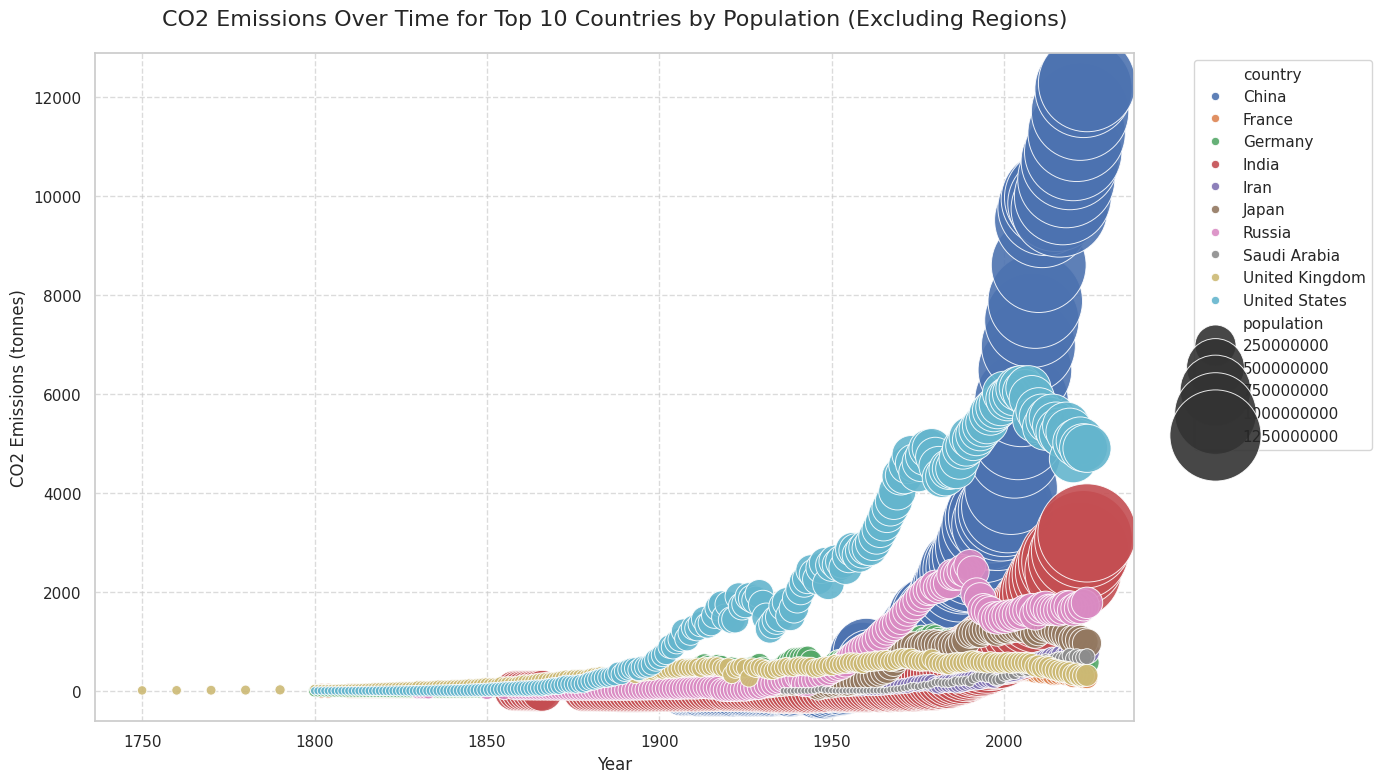

This bubble chart also shows how time and Co2 changes for the top 10 countries. The sizes represent population


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)


# Exclude aggregate regions based on iso_code (as performed in a previous step)
df_countries = df[df['iso_code'].notnull()].copy()


# Additionally, explicitly exclude known aggregate regions that might have iso_codes or weren't caught
regions_to_exclude = [
   'World', 'European Union (27)', 'European Union (28)',
   'High-income countries', 'Low-income countries',
   'Lower-middle-income countries', 'Upper-middle-income countries',
   'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania',
   'International aviation', 'International shipping',
   'OECD (GCP)', 'Non-OECD (GCP)', 'Africa (GCP)', 'Asia (GCP)',
   'Europe (GCP)', 'North America (GCP)', 'South America (GCP)',
   'Oceania (GCP)', 'Least developed countries (Jones et al.)', 'Kosovo', 'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)'
]


df_countries = df_countries[~df_countries['country'].isin(regions_to_exclude)].copy()




# Calculate average CO2 emissions per country using df_countries
avg_co2_per_country = df_countries.groupby('country')['co2'].mean().sort_values(ascending=False)


# Select the top N countries for better visualization
n_countries = 10
top_n_countries_co2 = avg_co2_per_country.head(n_countries)

# Filter df_countries to only include the top N countries
df_top_countries = df_countries[df_countries['country'].isin(top_n_countries_co2.index)].copy()

# Drop rows with NaN values in 'co2' or 'population' for the bubble chart
df_top_countries.dropna(subset=['co2', 'population'], inplace=True)

plt.figure(figsize=(14, 8))

# Bubble Chart: CO2 emissions over time for top N countries, with bubble size representing population
sns.scatterplot(
    data=df_top_countries,
    x='year',
    y='co2',
    hue='country',  # Differentiate countries by color
    size='population', # Size of the points based on population
    sizes=(20, 5000), # Range of bubble sizes
    alpha=0.9,
    legend='brief'      # Show full legend for hue and size
)

plt.title(f'CO2 Emissions Over Time for Top {n_countries} Countries by Population (Excluding Regions)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Emissions (tonnes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout()
plt.show()

print("This bubble chart also shows how time and Co2 changes for the top 10 countries. The sizes represent population")

<Axes: xlabel='gdp', ylabel='co2'>

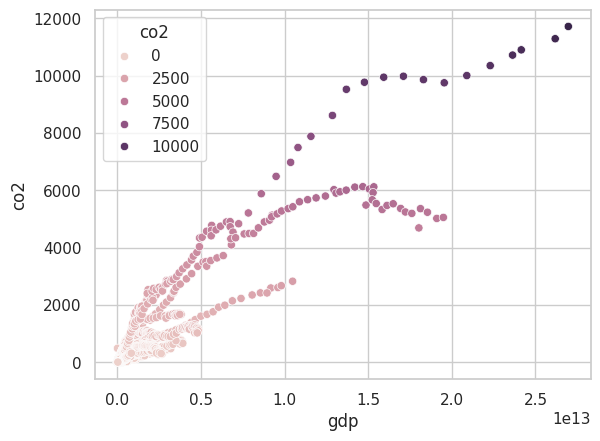

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

regions_to_exclude = [
   'World', 'European Union (27)', 'European Union (28)',
   'High-income countries', 'Low-income countries',
   'Lower-middle-income countries', 'Upper-middle-income countries',
   'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania',
   'International aviation', 'International shipping',
   'OECD (GCP)', 'Non-OECD (GCP)', 'Africa (GCP)', 'Asia (GCP)',
   'Europe (GCP)', 'North America (GCP)', 'South America (GCP)',
   'Oceania (GCP)', 'Least developed countries (Jones et al.)', 'Kosovo', 'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)'
]

df_countries = df[df['iso_code'].notnull()].copy()


df_countries = df_countries[~df_countries['country'].isin(regions_to_exclude)].copy()



# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)


sns.scatterplot(
    data=df_countries,
    x='gdp',
    y='co2',
    hue='co2'
)

<Axes: xlabel='population', ylabel='co2'>

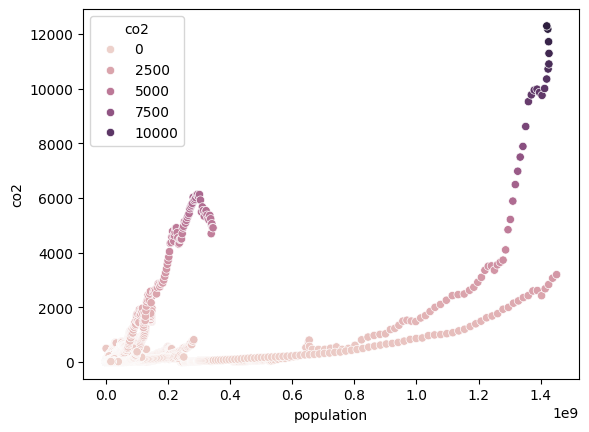

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

regions_to_exclude = [
   'World', 'European Union (27)', 'European Union (28)',
   'High-income countries', 'Low-income countries',
   'Lower-middle-income countries', 'Upper-middle-income countries',
   'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania',
   'International aviation', 'International shipping',
   'OECD (GCP)', 'Non-OECD (GCP)', 'Africa (GCP)', 'Asia (GCP)',
   'Europe (GCP)', 'North America (GCP)', 'South America (GCP)',
   'Oceania (GCP)', 'Least developed countries (Jones et al.)', 'Kosovo', 'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)'
]

df_countries = df[df['iso_code'].notnull()].copy()


df_countries = df_countries[~df_countries['country'].isin(regions_to_exclude)].copy()

sns.scatterplot(
    data=df_countries,
    x='population',
    y='co2',
    hue='co2'
)

# **STATISTICAL SIGNIFICANCE**


### Statistical Significance: Population and CO2 Levels

To assess if there's a statistically significant relationship between a country's population and its CO2 emissions, we can calculate the Pearson correlation coefficient. This coefficient measures the linear relationship between two datasets. A p-value associated with this correlation will tell us how likely it is to observe such a correlation by random chance if there were no actual relationship.

- **Pearson Correlation Coefficient (r):** Ranges from -1 to +1. A value close to +1 indicates a strong positive linear relationship (as one increases, the other tends to increase). A value close to -1 indicates a strong negative linear relationship. A value close to 0 indicates a weak or no linear relationship.
- **P-value:** If the p-value is less than a chosen significance level (commonly 0.05), we can conclude that there is a statistically significant linear relationship between the two variables.






### **NOTICE**


The null hypothesis for the Pearson correlation coefficient that we calculated was that there is no linear relationship between the population of countries and their CO2 emissions. In other words, it states that the true Pearson correlation coefficient (ρ) between these two variables is equal to zero (ρ = 0).



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr
import numpy as np

# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

# Exclude aggregate regions (as done in previous cleaning steps)
df_countries = df[df['iso_code'].notnull() & ~df['iso_code'].str.startswith('OWID').fillna(False)].copy()

# Drop rows where either 'gdp' or 'co2' is NaN for correlation calculation
df_correlation_gdp_co2 = df_countries.dropna(subset=['gdp', 'co2']).copy()

# Let's calculate r for GDP and CO2
r_value, p_value = pearsonr(df_correlation_gdp_co2['gdp'], df_correlation_gdp_co2['co2'])

if np.isnan(p_value):
    print("Error: Correlation could not be calculated due to insufficient valid data points.")
else:
    print(f"Pearson Correlation Coefficient between GDP and CO2: r = {r_value:.2f}")
    print(f"P-value: {p_value:.4f}")

    # Interpret the results
    alpha = 0.05 # Significance level

    if p_value < alpha:
        print(f"""\nWith a p-value of {p_value:.4f} (less than {alpha}), we reject the null hypothesis.
This suggests a statistically significant linear relationship between GDP and CO2 emissions.""")
        if r_value > 0:
            print(f"The correlation is positive, meaning that as GDP increases, CO2 emissions tend to increase.")
        else:
            print(f"The correlation is negative, meaning that as GDP increases, CO2 emissions tend to decrease.")
    else:
        print(f"""\nWith a p-value of {p_value:.4f} (greater than or equal to {alpha}), we fail to reject the null hypothesis.
This suggests no statistically significant linear relationship between GDP and CO2 emissions.""")

Pearson Correlation Coefficient between GDP and CO2: r = 0.92
P-value: 0.0000

With a p-value of 0.0000 (less than 0.05), we reject the null hypothesis.
This suggests a statistically significant linear relationship between GDP and CO2 emissions.
The correlation is positive, meaning that as GDP increases, CO2 emissions tend to increase.


/tmp/ipykernel_1661/2521394434.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_countries = df[df['iso_code'].notnull() & ~df['iso_code'].str.startswith('OWID').fillna(False)].copy()


In [ ]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

df_countries = df[df['iso_code'].notnull()].copy()


# Drop rows where either 'population' or 'co2' is NaN for correlation calculation
# The .copy() is used to avoid SettingWithCopyWarning
df_correlation = df_countries.dropna(subset=['population', 'co2']).copy()

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(df_correlation['population'], df_correlation['co2'])

print(f"Pearson Correlation Coefficient between Population and CO2: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print(f"\nWith a p-value of {p_value:.4f} (less than {alpha}), we reject the null hypothesis.\nThis suggests a statistically significant linear relationship between population and CO2 emissions.")
    if correlation_coefficient > 0:
        print(f"The correlation is positive, meaning that as population increases, CO2 emissions tend to increase.")
    else:
        print(f"The correlation is negative, meaning that as population increases, CO2 emissions tend to decrease.")
else:
    print(f"\nWith a p-value of {p_value:.4f} (greater than or equal to {alpha}), we fail to reject the null hypothesis.\nThis suggests no statistically significant linear relationship between population and CO2 emissions.")

Pearson Correlation Coefficient between Population and CO2: 0.6316
P-value: 0.0000

With a p-value of 0.0000 (less than 0.05), we reject the null hypothesis.
This suggests a statistically significant linear relationship between population and CO2 emissions.
The correlation is positive, meaning that as population increases, CO2 emissions tend to increase.


In [8]:
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

df_countries = df[df['iso_code'].notnull()].copy()


# Drop rows where either 'gdp' or 'co2' is NaN for correlation calculation
# The .copy() is used to avoid SettingWithCopyWarning
df_correlation = df_countries.dropna(subset=['gdp', 'co2']).copy()

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(df_correlation['gdp'], df_correlation['co2'])

print(f"Pearson Correlation Coefficient between gdp and CO2: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05 # Significance level

if p_value < alpha:
    print(f"\nWith a p-value of {p_value:.4f} (less than {alpha}), we reject the null hypothesis.\nThis suggests a statistically significant linear relationship between gdp and CO2 emissions.")
    if correlation_coefficient > 0:
        print(f"The correlation is positive, meaning that as gdp increases, CO2 emissions tend to increase.")
    else:
        print(f"The correlation is negative, meaning that as gdp increases, CO2 emissions tend to decrease.")
else:
    print(f"\nWith a p-value of {p_value:.4f} (greater than or equal to {alpha}), we fail to reject the null hypothesis.\nThis suggests no statistically significant linear relationship between gdp and CO2 emissions.")

Pearson Correlation Coefficient between gdp and CO2: 0.9249
P-value: 0.0000

With a p-value of 0.0000 (less than 0.05), we reject the null hypothesis.
This suggests a statistically significant linear relationship between gdp and CO2 emissions.
The correlation is positive, meaning that as gdp increases, CO2 emissions tend to increase.


# **LINEAR REGRESSION**


### Linear Regression: Population vs. CO2 Levels

Linear regression is a statistical method that allows us to model the relationship between a dependent variable (in this case, CO2 emissions) and one or more independent variables (population). The goal is to find the best-fitting straight line through the data points.

- **Model Equation:** `CO2 = Intercept + (Coefficient * Population)`
- **Intercept:** The predicted CO2 emissions when the population is zero.
- **Coefficient (for Population):** The expected change in CO2 emissions for every one-unit increase in population.
- **R-squared:** A measure that indicates the proportion of the variance in the dependent variable (CO2) that can be predicted from the independent variable (population). A higher R-squared value means the model explains more of the variability.
- **P-value (for Coefficient):** Indicates the statistical significance of the population coefficient. If it's below 0.05, it suggests that population is a statistically significant predictor of CO2 emissions.

In [9]:
import statsmodels.formula.api as smf

# Create the linear regression model using the `df_correlation` DataFrame
# The formula 'co2 ~ population' means 'co2 is predicted by population'
model = smf.ols('co2 ~ population', data=df_correlation).fit()

# Print the model summary
print(model.summary())

# Extract key results
intercept = model.params['Intercept']
population_coeff = model.params['population']
r_squared = model.rsquared
p_value_coeff = model.pvalues['population']

print(f"\nLinear Regression Results:")
print(f"  Intercept: {intercept:.2f}")
print(f"  Coefficient for Population: {population_coeff:.6f}")
print(f"  R-squared: {r_squared:.4f}")
print(f"  P-value for Population Coefficient: {p_value_coeff:.4f}")

# Interpretation
print(f"\nInterpretation:")
print(f"  - For every unit increase in population, CO2 emissions are predicted to increase by {population_coeff:.6f} tonnes.")
print(f"  - Approximately {r_squared*100:.2f}% of the variance in CO2 emissions can be explained by population.")
if p_value_coeff < 0.05:
    print(f"  - The population coefficient is statistically significant (p < 0.05).")
else:
    print(f"  - The population coefficient is not statistically significant (p >= 0.05).")

                            OLS Regression Results                            
Dep. Variable:                    co2   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     9554.
Date:                Thu, 23 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:42:05   Log-Likelihood:            -1.0882e+05
No. Observations:               14644   AIC:                         2.176e+05
Df Residuals:                   14642   BIC:                         2.177e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     20.5438      3.508      5.857      0.0

### Visualizing the Linear Regression

To better understand the relationship, let's visualize the data points and the fitted regression line. This plot will show how well the linear model captures the trend in the data.

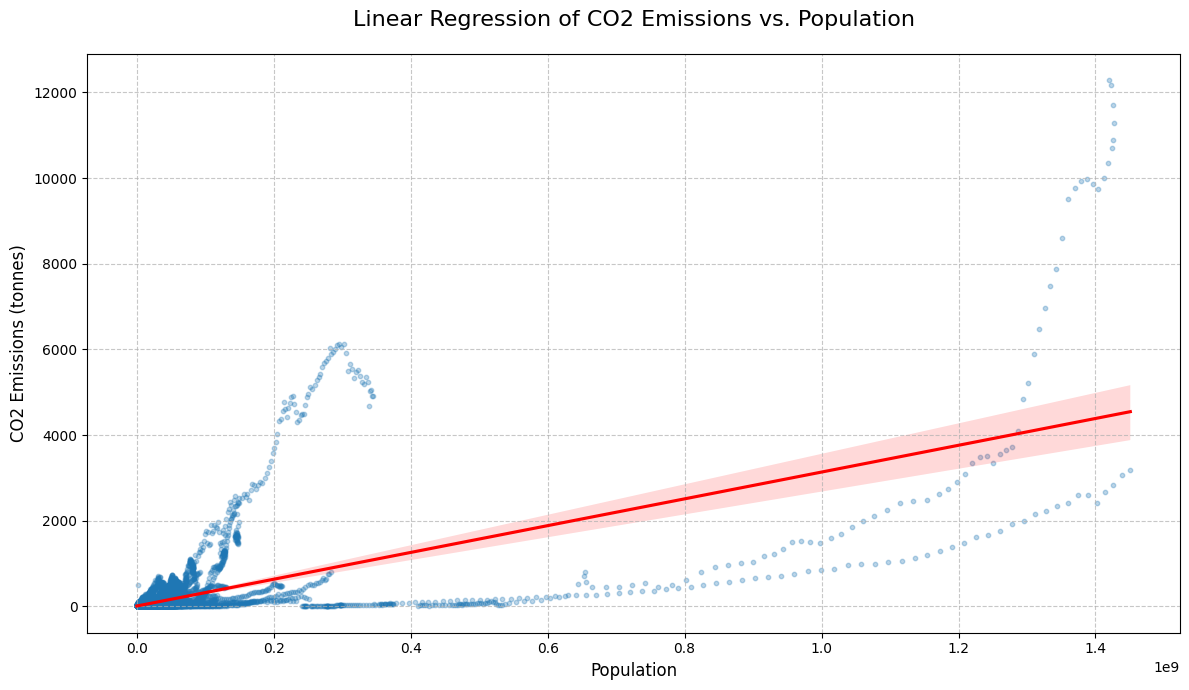

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.regplot(x='population', y='co2', data=df_correlation, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

plt.title('Linear Regression of CO2 Emissions vs. Population', fontsize=16, pad=20)
plt.xlabel('Population', fontsize=12)
plt.ylabel('CO2 Emissions (tonnes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **DATA INFO**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)



df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)



df.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,1755,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,1756,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,1757,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,1758,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,1759,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **MACHINE LEARNING**

In [3]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df is defined
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

# Exclude aggregate regions (as done in previous cleaning steps)
df_filtered = df[df['iso_code'].notnull() & ~df['iso_code'].str.startswith('OWID').fillna(False)].copy()

# Drop rows where 'gdp' or 'co2' are NaN, as these are critical for the model
df_filtered.dropna(subset=['gdp', 'co2'], inplace=True)

# Prepare features (X) and label (y) from the filtered DataFrame
X = df_filtered[['country', 'gdp']].copy() # the features (clues) - two column names
y = df_filtered['co2'].copy()     # the label (answer) - one column name

# One-hot encode the 'country' column in X
X = pd.get_dummies(X, columns=['country'], drop_first=True)

print("Features (X) shape:", X.shape)
print("Label (y) shape:", y.shape)


# Fill in the two blanks
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # what fraction goes in the vault? (20% as a decimal)
    random_state=42    # the repeatable-shuffle number
)

print("Training Co2 (the model studies these):", len(X_train))
print("Test CO2 (locked in the vault):        ", len(X_test))

Features (X) shape: (14672, 164)
Label (y) shape: (14672,)
Training Co2 (the model studies these): 11737
Test CO2 (locked in the vault):         2935


/tmp/ipykernel_3960/23080485.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_filtered = df[df['iso_code'].notnull() & ~df['iso_code'].str.startswith('OWID').fillna(False)].copy()


In the code above, the machine learning AI sets 20% of data in the vault, and studies 80% in the vault.

In [4]:
from sklearn.neighbors import KNeighborsRegressor # Changed from KNeighborsClassifier

# Step 1: create the model - ask 5 neighbors
model = KNeighborsRegressor(n_neighbors=5) # Changed from KNeighborsClassifier

# Step 2: TRAIN - fill in which data the model studies
model.fit(X_train, y_train)

# Step 3: SCORE - fill in which data is exam day
accuracy = model.score(X_test, y_test) # For regressors, .score() typically returns R-squared

print(f"🎉 Your first ML model's R-squared: {accuracy:.3f}") # Changed output message for R-squared
print("That means: the model explains about 78.5% much of the variance in CO2 emissions.")
print(f"The R-squared value of {accuracy:.3f} indicates how well future CO2 emissions are predicted based on the unseen data.")

🎉 Your first ML model's R-squared: 0.785
That means: the model explains about 78.5% much of the variance in CO2 emissions.
The R-squared value of 0.785 indicates how well future CO2 emissions are predicted based on the unseen data.


This Code trains the machine learning model with a K-Nearest Neighbors Regressor.


In [5]:
# ✅ Verification cell
assert model.n_neighbors == 5, "Model should use 5 neighbors."
assert 0.5 < accuracy <= 1.0, "Something's off - accuracy should be well above a coin flip. Did you fit on the training set and score on the test set?"
print("✅ You just trained and tested a real machine learning model. Welcome to ML!")


✅ You just trained and tested a real machine learning model. Welcome to ML!


In [6]:
# Run this cell - the laziest model in the world
from sklearn.dummy import DummyRegressor # Changed from DummyClassifier

lazy_model = DummyRegressor(strategy='mean')  # Use 'mean' strategy for regression baseline
lazy_model.fit(X_train, y_train)
lazy_accuracy = lazy_model.score(X_test, y_test) # For regressors, .score() returns R-squared

print(f"Lazy baseline (always predict mean):  {lazy_accuracy:.3f}") # Adjusted output for R-squared
print(f"Your k-NN model:                  {accuracy:.3f}") # Adjusted output for R-squared
print(f"Real learning (the difference):   {accuracy - lazy_accuracy:+.3f}") # Adjusted output for R-squared

Lazy baseline (always predict mean):  -0.004
Your k-NN model:                  0.785
Real learning (the difference):   +0.789


In [7]:
from sklearn.linear_model import LinearRegression

# Step 1: Create the Linear Regression model
linear_model = LinearRegression()

# Step 2: TRAIN the model using the training data
linear_model.fit(X_train, y_train)

# Step 3: SCORE the model using the test data (R-squared)
linear_accuracy = linear_model.score(X_test, y_test)

print(f"Linear Regression Model R-squared: {linear_accuracy:.3f}")
print(f"This means the Linear Regression model explains approximately {linear_accuracy*100:.1f}% of the variance in CO2 emissions.")

Linear Regression Model R-squared: 0.785
This means the Linear Regression model explains approximately 78.5% of the variance in CO2 emissions.


This code block implements a **Linear Regression** model. It's a fundamental machine learning algorithm that models the relationship between a dependent variable (CO2 emissions) and one or more independent variables (country and GDP) by fitting a linear equation to observed data.

- **`LinearRegression()`**: Initializes the linear regression model.
- **`linear_model.fit(X_train, y_train)`**: Trains the model using the training features (`X_train`) and their corresponding CO2 emissions (`y_train`). The model learns the optimal coefficients for each feature.
- **`linear_model.score(X_test, y_test)`**: Calculates the R-squared value on the unseen test data. R-squared indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R-squared (closer to 1) means the model provides a better fit to the data.


This code creates a "lazy" baseline regression model (DummyRegressor) that simply predicts the average CO2 emission for all data points. Its R-squared value (lazy_accuracy) is then compared to your KNeighborsRegressor model's R-squared (accuracy). The Real learning value shows how much better your k-NN model performs compared to this basic average prediction.

# **DATA ANALYSIS**

In [ ]:
# Find the most recent year in our cleaned dataset
latest_year = df_clean['year'].max()

# Filter for that year and get the top 10 emitters
top_emitters = df_clean[df_clean['year'] == latest_year].nlargest(10, 'co2')

print(f"Top 10 CO2 Emitters in {latest_year} (in Million Tonnes):")
print(top_emitters[['country', 'co2', 'co2_per_capita', 'population']])

Top 10 CO2 Emitters in 2024 (in Million Tonnes):
             country        co2  co2_per_capita    population
9933           China  12289.037           8.658  1.419321e+09
48007  United States   4904.120          14.197  3.454266e+08
21762          India   3193.478           2.201  1.450936e+09
38314         Russia   1780.524          12.295  1.448204e+08
23812          Japan    961.867           7.772  1.237530e+08
21937      Indonesia    812.220           2.865  2.834879e+08
22662           Iran    792.631           8.656  9.156774e+07
40289   Saudi Arabia    692.133          20.379  3.396275e+07
43038    South Korea    583.679          11.286  5.171759e+07
18319        Germany    572.319           6.769  8.455223e+07


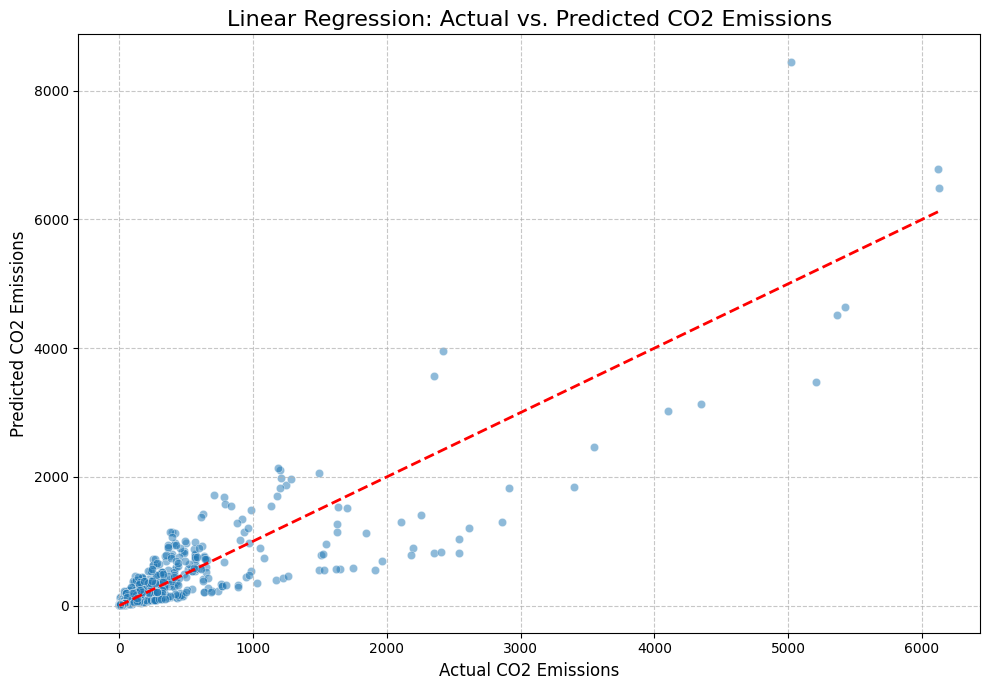

In [10]:
# Make predictions on the test set using the Linear Regression model
y_pred_linear = linear_model.predict(X_test)

# Create a DataFrame for easier plotting
predictions_df = pd.DataFrame({'Actual CO2': y_test, 'Predicted CO2 (Linear)': y_pred_linear})

# Visualize actual vs. predicted CO2 emissions
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual CO2', y='Predicted CO2 (Linear)', data=predictions_df, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.title('Linear Regression: Actual vs. Predicted CO2 Emissions', fontsize=16)
plt.xlabel('Actual CO2 Emissions', fontsize=12)
plt.ylabel('Predicted CO2 Emissions', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This scatter plot visualizes the performance of the Linear Regression model:

- Each point represents a country-year observation from the **test set**.
- The **x-axis** shows the actual CO2 emissions for that observation.
- The **y-axis** shows the CO2 emissions predicted by our Linear Regression model.
- The **red dashed line** represents a perfect prediction, where actual values equal predicted values.

Points clustered closely around the red line indicate good model performance, meaning the model's predictions are close to the true values. Points further away show instances where the model's prediction deviates more significantly from reality.

# **CONCLUSION**

In conclusuion, My results and data shows that countries that have a higher population & GDP have higher CO2 emissions. My charts show the Top 10 countries that create CO2 emissions. The #1 country that does the most Co2 emssions is China, which also has the highest population & has a high GDP. We also used Machine Learning models to train it on correlations between pPopulation & GDP, and Co2. Thus, my data shows that countries that have a higher population & GDP have higher CO2 emissions.